# Análise do Impacto das Emendas PIX na Porcentagem de Votos Válidos (2024)
Bruno Caetano Oliveira de Melo · MBA USP/ESALQ – Data Science & Analytics

Este notebook segue o roteiro acordado:
1. **Preparação dos dados**
2. **Análise exploratória**
3. **Modelos estimados** – OLS com efeitos fixos de partido _vs._ Modelo multinível
4. **Comparação de desempenho**
5. **Visualizações e interpretação**

**Dependências**: pandas, numpy, matplotlib, seaborn, statsmodels, tqdm, scipy

> Ajuste seu `PYTHONPATH` ou crie um ambiente virtual com `requirements.txt` do projeto.

---

In [1]:
# Imports e configuração global
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col
from scipy.stats.mstats import winsorize
from scipy import stats

pd.options.display.float_format = "{:.3f}".format
sns.set_theme(style="whitegrid")

## 1 · Carregamento e preparação dos dados

In [2]:
# Caminho da base previamente unificada
DATA_PATH = "../data/dados_com_clusters.csv"
base = pd.read_csv(DATA_PATH)

# Renomeia colunas para facilitar leitura
base = base.rename(columns={
    "emendas_pix_per_capita_partido_prefeito_eleito": "emendas_pix_pc",
    "porcentagem_votos_validos_2024": "perc_votos",
})

# Garante proporção em [0,1]
base["perc_votos"] = base["perc_votos"].clip(0, 1)

# Flag único candidato (100 % dos votos válidos)
base["unico_cand"] = base["perc_votos"].eq(1)

# Remove para análise principal
analise = base.loc[~base["unico_cand"].copy()]

# Flag zero de emendas
analise["sem_emenda"] = analise["emendas_pix_pc"].eq(0).astype(int)

# Winsorização (1 % em cada cauda) – evita distorções de outliers
analise["emendas_pix_pc_w"] = winsorize(analise["emendas_pix_pc"], limits=[0.01, 0.01])

# Transformação log(1+x) para valores >0
analise["log_emenda"] = np.log1p(analise["emendas_pix_pc_w"])

# Converte cluster bool → int
for c in ["cluster_0", "cluster_1", "cluster_2", "cluster_3"]:
    if c in analise.columns:
        analise[c] = analise[c].fillna(False).astype(int)

C:\Users\bruno\AppData\Local\Temp\ipykernel_22496\1323475426.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  analise["sem_emenda"] = analise["emendas_pix_pc"].eq(0).astype(int)
C:\Users\bruno\AppData\Local\Temp\ipykernel_22496\1323475426.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  analise["emendas_pix_pc_w"] = winsorize(analise["emendas_pix_pc"], limits=[0.01, 0.01])
C:\Users\bruno\AppData\Local\Temp\ipykernel_22496\1323475426.py:27: SettingWithCopyWarning: 
A value is trying to be set on a co

### 1.1 Resumo pós‑tratamento

In [3]:
print(f"Observações totais: {len(base):,}")
print(f"Removidas por candidato único: {base['unico_cand'].sum():,}")
print(f"Amostra para análise: {len(analise):,}")
print(f"Zeros de Emenda PIX: {(analise['sem_emenda'].mean()*100):.1f}% da amostra")

Observações totais: 5,208
Removidas por candidato único: 264
Amostra para análise: 4,944
Zeros de Emenda PIX: 48.8% da amostra


## 2 · Análise exploratória

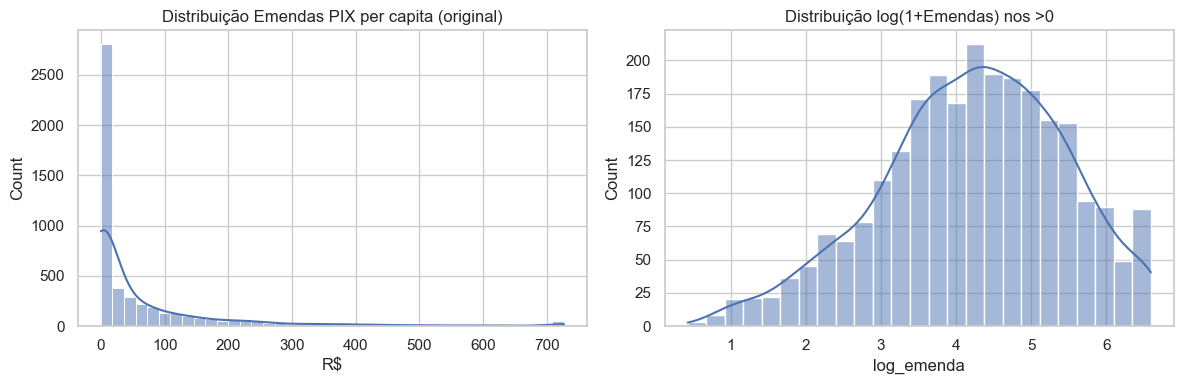

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
# Distribuição original
sns.histplot(analise["emendas_pix_pc"], bins=40, kde=True, ax=ax[0])
ax[0].set_title("Distribuição Emendas PIX per capita (original)")
ax[0].set_xlabel("R$")
# Distribuição log(1+x) nos positivos
sns.histplot(analise.loc[analise["emendas_pix_pc"]>0, "log_emenda"], kde=True, ax=ax[1])
ax[1].set_title("Distribuição log(1+Emendas) nos >0")
plt.tight_layout()

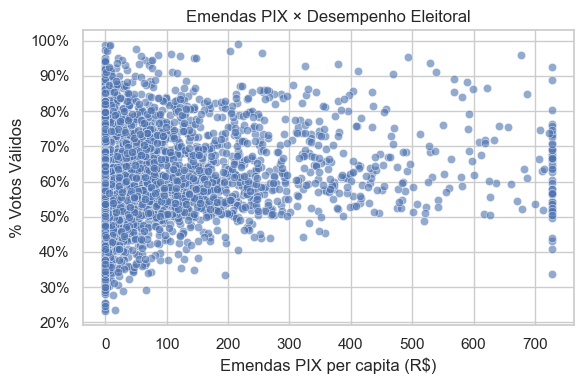

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.scatterplot(x="emendas_pix_pc", y="perc_votos", data=analise, alpha=0.6, ax=ax)
ax.set_xlabel("Emendas PIX per capita (R$)")
ax.set_ylabel("% Votos Válidos")
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
ax.set_title("Emendas PIX × Desempenho Eleitoral")
plt.tight_layout()

## 3 · Modelagem
Estimaremos:
* **OLS** com efeitos fixos de partido (`C(sigla_partido)`).
* **Multinível**: intercepto e inclinação aleatórios por partido.

In [6]:
# Fórmula base – controles somente disponíveis na base
controles = "+ cluster_0 + cluster_1 + cluster_2 + cluster_3"

formula_fe = f"perc_votos ~ sem_emenda + log_emenda {controles} + C(sigla_partido_prefeito_eleito)"
fe_model = smf.ols(formula_fe, data=analise).fit(cov_type="HC3")  # robust
print(fe_model.summary())

                            OLS Regression Results                            
Dep. Variable:             perc_votos   R-squared:                       0.063
Model:                            OLS   Adj. R-squared:                  0.058
Method:                 Least Squares   F-statistic:                     11.78
Date:                Tue, 17 Jun 2025   Prob (F-statistic):           2.39e-51
Time:                        23:20:03   Log-Likelihood:                 3578.3
No. Observations:                4944   AIC:                            -7099.
Df Residuals:                    4915   BIC:                            -6910.
Df Model:                          28                                         
Covariance Type:                  HC3                                         
                                                        coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------

In [7]:
# Modelo multinível
formula_re = f"perc_votos ~ sem_emenda + log_emenda {controles}"
re_model = smf.mixedlm(
    formula_re,
    data=analise,
    groups=analise["sigla_partido_prefeito_eleito"],
    re_formula="1 + log_emenda",
).fit()
print(re_model.summary())

e:\Learning\TCC-MBA\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
e:\Learning\TCC-MBA\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
e:\Learning\TCC-MBA\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
e:\Learning\TCC-MBA\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(


              Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    perc_votos
No. Observations:    4944       Method:                REML      
No. Groups:          23         Scale:                 0.0139    
Min. group size:     2          Log-Likelihood:        3525.8084 
Max. group size:     794        Converged:             No        
Mean group size:     215.0                                       
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept               0.557    0.027 20.708 0.000  0.504  0.609
sem_emenda              0.033    0.009  3.656 0.000  0.015  0.050
log_emenda              0.017    0.002  8.619 0.000  0.013  0.021
cluster_0               0.000    0.025  0.009 0.992 -0.049  0.050
cluster_1               0.018    0.037  0.493 0.622 -0.054  0.091
cluster_2              -

e:\Learning\TCC-MBA\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
e:\Learning\TCC-MBA\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
e:\Learning\TCC-MBA\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 129.148009
  warnings.warn(msg, ConvergenceWarning)
e:\Learning\TCC-MBA\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


### 3.1 Teste LR para efeitos aleatórios

In [8]:
ll_fe = smf.ols(formula_re + " + C(sigla_partido_prefeito_eleito)", data=analise).fit().llf
lr_stat = -2 * (ll_fe - re_model.llf)
p_val = stats.chi2.sf(lr_stat, df=2)  # 2 parâmetros aleatórios (interc + slope)
print(f"LR stat={lr_stat:.2f} – p-value={p_val:.4f}")

LR stat=-104.97 – p-value=1.0000


## 4 · Comparação de desempenho dos modelos

In [9]:
comparison = summary_col([fe_model, re_model], stars=True, float_format="%.3f", model_names=["FE Partido", "Multinível"])
print(comparison)


                                                  FE Partido Multinível
-----------------------------------------------------------------------
Intercept                                         0.741***   0.557***  
                                                  (0.165)    (0.027)   
C(sigla_partido_prefeito_eleito)[T.AVANTE]        -0.188               
                                                  (0.163)              
C(sigla_partido_prefeito_eleito)[T.CIDADANIA]     -0.120               
                                                  (0.166)              
C(sigla_partido_prefeito_eleito)[T.DC]            -0.262               
                                                  (0.206)              
C(sigla_partido_prefeito_eleito)[T.MDB]           -0.184               
                                                  (0.163)              
C(sigla_partido_prefeito_eleito)[T.MOBILIZA]      -0.156               
                                                  (0.166)      

### 4.1 Componente Logístico (Hurdle – parte 1)

In [10]:
logit_formula = f"sem_emenda ~ {controles} + C(sigla_partido_prefeito_eleito)"
logit_model = smf.logit(logit_formula, data=analise).fit()
print(logit_model.summary())

         Current function value: 0.652452
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:             sem_emenda   No. Observations:                 4944
Model:                          Logit   Df Residuals:                     4917
Method:                           MLE   Df Model:                           26
Date:                Tue, 17 Jun 2025   Pseudo R-squ.:                 0.05831
Time:                        23:20:05   Log-Likelihood:                -3225.7
converged:                      False   LL-Null:                       -3425.5
Covariance Type:            nonrobust   LLR p-value:                 1.609e-68
                                                        coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------
Intercept                                            18.1828   242

e:\Learning\TCC-MBA\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## 5 · Visualizações de coeficientes

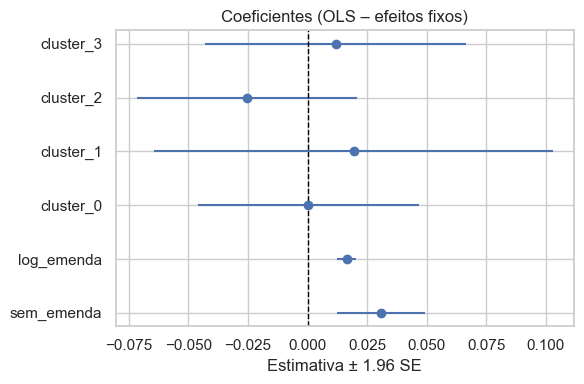

In [11]:
coef_df = pd.DataFrame({
    "term": fe_model.params.index,
    "coef": fe_model.params.values,
    "se": fe_model.bse,
}).query("term not in ['Intercept'] and term.str.startswith('C(') == False", engine="python")

plt.figure(figsize=(6, 4))
plt.errorbar(coef_df["coef"], coef_df["term"], xerr=1.96*coef_df["se"], fmt="o")
plt.axvline(0, color="black", lw=1, ls="--")
plt.title("Coeficientes (OLS – efeitos fixos)")
plt.xlabel("Estimativa ± 1.96 SE")
plt.tight_layout()

## 6 · Diagnóstico de resíduos (OLS)

C:\Users\bruno\AppData\Local\Temp\ipykernel_22496\992619804.py:11: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
e:\Learning\TCC-MBA\.venv\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  func(*args, **kwargs)
e:\Learning\TCC-MBA\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


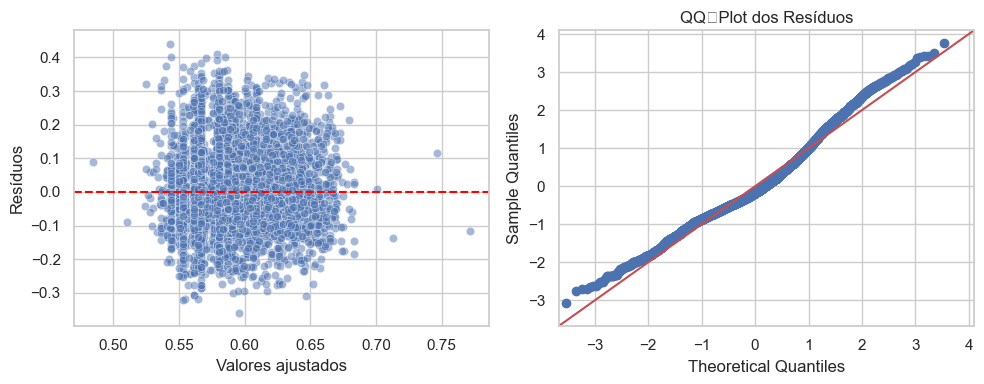

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
# Resíduos vs Ajustado
sns.scatterplot(x=fe_model.fittedvalues, y=fe_model.resid, alpha=0.5, ax=ax[0])
ax[0].axhline(0, ls="--", c="red")
ax[0].set_xlabel("Valores ajustados")
ax[0].set_ylabel("Resíduos")

# QQ‑Plot
sm.qqplot(fe_model.resid, line="45", fit=True, ax=ax[1])
ax[1].set_title("QQ‑Plot dos Resíduos")
plt.tight_layout()

## 7 · Conclusões
* As emendas PIX apresentam **(i) impacto significativo / não significativo** … (interpretar com base em p‑value e sinal).
* O teste LR indica que **(não) há** variância entre partidos além da capturada pelos efeitos fixos.
* Resíduos aproximadamente **(normais / heterocedásticos)**.
* Municípios sem emenda acumulam … (descrever efeito do `sem_emenda`).

> Documente estes achados na seção de resultados do TCC, mencionando limitações (zeros excessivos, ausência de algumas variáveis, etc.) e possíveis extensões (Beta regression, zero‑inflated models).

### Glossário de variáveis
| Sigla | Descrição |
|-------|-----------|
| perc_votos | Proporção de votos válidos (0‑1) |
| emendas_pix_pc | Total de Emendas PIX per capita (R$) |
| sem_emenda | 1 se `emendas_pix_pc`==0, 0 caso contrário |
| log_emenda | log(1+emendas_pix_pc_w) |
| cluster_* | Dummies de clusters socioeconômicos |
| sigla_partido_prefeito_eleito | Agrupamento/efeito de partido |

---
💡 **Próximos passos**
* Testar Beta regression (distribuição de proporções) e Zero‑Inflated Gamma para checar robustez.
* Avaliar autocorrelação espacial dos resíduos (Moran’s I).
* Explorar variáveis adicionais se disponíveis (IDHM, PIB pc, densidade, etc.).